# Cosine Similarity Between Random Activation Points

Quick notebook for sampling random token-level activation vectors from an activation shard directory and visualizing their pairwise cosine similarities.

The default samples layer 5 from a small deterministic Wikipedia slice when that scratch path is available.

## 1. Setup

In [26]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "src/dalg").exists():
            return path
    raise RuntimeError(f"Could not find repo root from {start}")


REPO = find_repo_root()
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dalg.data.shard_activations import ActivationBatchDataset, load_meta_index
from dalg.data.subset_spec import resolve_spec_positions, split_shard_dir_spec


# --------------------------------------------------------------- parameters
LAYER = 5
K = 1000
SUBSET_SPEC = "pile_wikipedia_100K"
N_POINTS = 2_000
N_HEATMAP = 128
BATCH_SIZE = 8_192
SEED = 0
DROP_PREFIX = None  # None uses the value saved in config.json
CENTER_BEFORE_COSINE = False
KMEDOIDS_RUN = REPO / "outputs/experiments/pile_wikipedia_100K_layer05_kmedoids/full_100k_clean"
AXIS_SOURCE = "points_mean"  # points_mean, normalized_points_mean, medoids_mean, normalized_medoids_mean
ASSIGNMENT_CHUNK_SIZE = 20_000
SAVE_PROJECTED_ASSIGNMENTS = True


candidate_roots = [
    REPO / "dalg-cache/pile_gemma2b_activations",
    Path("/orfeo/scratch/dssc/zenocosini/dalg-cache/pile_gemma2b_activations"),
]
for root in candidate_roots:
    if root.exists():
        SHARD_DIR = f"{root}#{SUBSET_SPEC}"
        break
else:
    SHARD_DIR = f"{candidate_roots[0]}#{SUBSET_SPEC}"

print(f"repo: {REPO}")
print(f"shard dir: {SHARD_DIR}")

repo: /orfeo/cephfs/scratch/dssc/malessi/decomposing-activations-local-geometry
shard dir: /orfeo/scratch/dssc/zenocosini/dalg-cache/pile_gemma2b_activations#pile_wikipedia_100K


## 2. Sample Random Points

In [27]:
clean_shard_dir, subset_spec = split_shard_dir_spec(SHARD_DIR)
cfg = json.loads((clean_shard_dir / "config.json").read_text())
window = int(cfg["window"])
drop_prefix = int(cfg.get("drop_prefix", 0) if DROP_PREFIX is None else DROP_PREFIX)

meta_index = load_meta_index(clean_shard_dir, LAYER)
positions = resolve_spec_positions(
    meta_index,
    subset_spec,
    window=window,
    drop_prefix=drop_prefix,
)

dataset = ActivationBatchDataset(
    clean_shard_dir,
    LAYER,
    row_subset=positions,
    batch_size=BATCH_SIZE,
    drop_prefix=drop_prefix,
    dtype=torch.float32,
    shuffle_shards=True,
    shuffle_within_shard=True,
    seed=SEED,
)

chunks = []
remaining = min(N_POINTS, dataset.num_items)
for xb in dataset:
    take = min(remaining, xb.shape[0])
    chunks.append(xb[:take].cpu())
    remaining -= take
    if remaining == 0:
        break

X = torch.cat(chunks, dim=0)
if CENTER_BEFORE_COSINE:
    X = X - X.mean(dim=0, keepdim=True)

display(pd.DataFrame([
    {"field": "layer", "value": LAYER},
    {"field": "subset_spec", "value": subset_spec},
    {"field": "resolved_rows", "value": len(positions)},
    {"field": "available_points", "value": dataset.num_items},
    {"field": "sampled_points", "value": X.shape[0]},
    {"field": "d_model", "value": X.shape[1]},
    {"field": "drop_prefix", "value": drop_prefix},
    {"field": "centered", "value": CENTER_BEFORE_COSINE},
]))

,field,value
0,layer,5
1,subset_spec,pile_wikipedia_100K
2,resolved_rows,447
3,available_points,100128
4,sampled_points,2000
5,d_model,2048
6,drop_prefix,32
7,centered,False


## 3. Pairwise Cosine Similarities

,cosine_similarity
count,3.998000e+06
mean,8.402970e-01
std,3.054984e-02
min,7.179327e-01
1%,7.746112e-01
5%,7.923387e-01
25%,8.197331e-01
50%,8.392439e-01
75%,8.591408e-01
95%,8.910953e-01


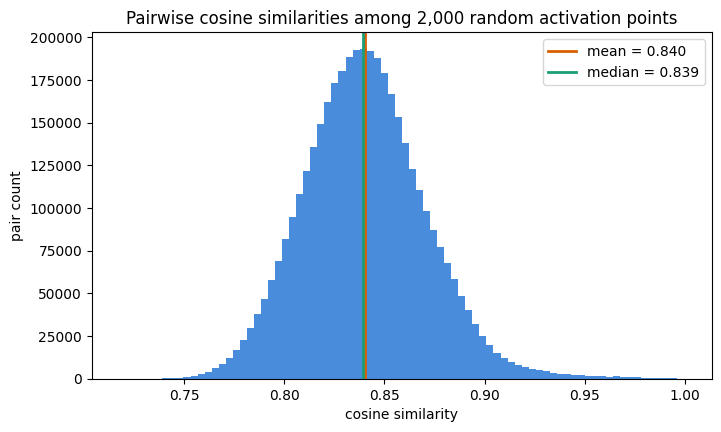

In [28]:
Xn = F.normalize(X, dim=1)
cos = Xn @ Xn.T

# Drop the diagonal self-similarities.
mask = ~torch.eye(cos.shape[0], dtype=torch.bool)
cos_values = cos[mask].numpy()

summary = pd.Series(cos_values).describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(summary.to_frame("cosine_similarity"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(cos_values, bins=80, color="#2a78d6", alpha=0.85)
ax.axvline(cos_values.mean(), color="#d95f02", linewidth=2, label=f"mean = {cos_values.mean():.3f}")
ax.axvline(np.median(cos_values), color="#1b9e77", linewidth=2, label=f"median = {np.median(cos_values):.3f}")
ax.set_title(f"Pairwise cosine similarities among {X.shape[0]:,} random activation points")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("pair count")
ax.legend()
plt.show()

## 4. Small Similarity Matrix

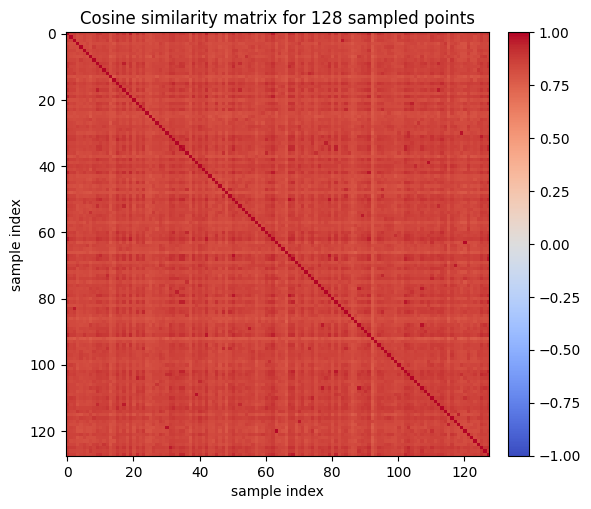

In [29]:
n = min(N_HEATMAP, Xn.shape[0])
heat = cos[:n, :n].numpy()

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(heat, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_title(f"Cosine similarity matrix for {n} sampled points")
ax.set_xlabel("sample index")
ax.set_ylabel("sample index")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 5. Centroid Cosine Similarities

centroids path: /orfeo/scratch/dssc/zenocosini/dalg-cache/pile_gemma2b_activations/centroids/k1000_L05/centroids.pt


,field,value
0,centroids,1000
1,d_model,2048
2,path,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...


,centroid_cosine_similarity
count,999000.000000
mean,0.947132
std,0.024930
min,0.815241
1%,0.883118
5%,0.904543
25%,0.930429
50%,0.947541
75%,0.966403
95%,0.985139


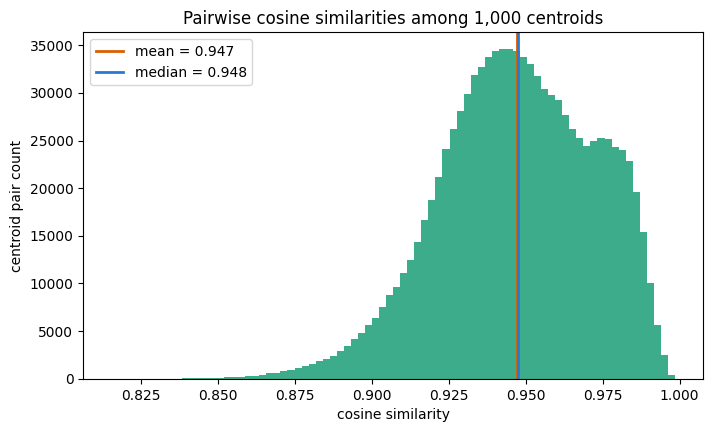

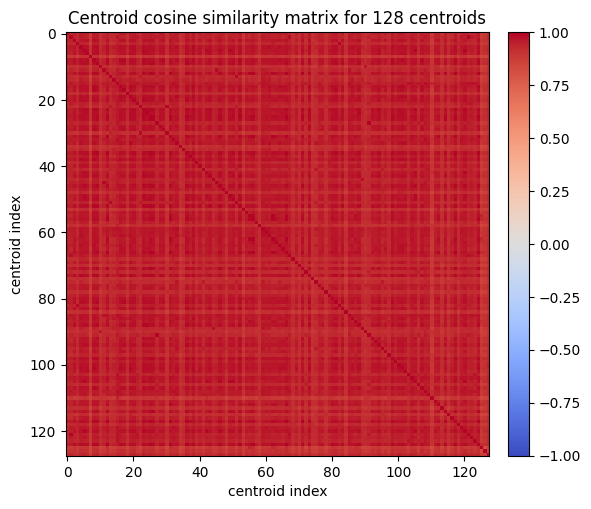

In [30]:
def load_centroid_tensor(path: Path) -> torch.Tensor:
    obj = torch.load(path, map_location="cpu")
    if isinstance(obj, dict):
        for key in ("centroids", "mu", "means"):
            if key in obj:
                obj = obj[key]
                break
    return obj.float()


centroid_candidates = [
    clean_shard_dir / f"centroids/k{K}_L{LAYER:02d}/centroids.pt",
    clean_shard_dir / f"layer{LAYER:02d}_{K}_10_component_sharded_mfa/centroids.pt",
    clean_shard_dir / f"layer{LAYER:02d}_{K}_10_mfa/centroids.pt",
]
CENTROIDS_PATH = next((p for p in centroid_candidates if p.exists()), centroid_candidates[0])
print(f"centroids path: {CENTROIDS_PATH}")

C = load_centroid_tensor(CENTROIDS_PATH)
if CENTER_BEFORE_COSINE:
    C = C - C.mean(dim=0, keepdim=True)

Cn = F.normalize(C, dim=1)
centroid_cos = Cn @ Cn.T
centroid_mask = ~torch.eye(centroid_cos.shape[0], dtype=torch.bool)
centroid_values = centroid_cos[centroid_mask].numpy()

display(pd.DataFrame([
    {"field": "centroids", "value": C.shape[0]},
    {"field": "d_model", "value": C.shape[1]},
    {"field": "path", "value": str(CENTROIDS_PATH)},
]))
display(pd.Series(centroid_values).describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("centroid_cosine_similarity"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(centroid_values, bins=80, color="#1b9e77", alpha=0.85)
ax.axvline(centroid_values.mean(), color="#d95f02", linewidth=2, label=f"mean = {centroid_values.mean():.3f}")
ax.axvline(np.median(centroid_values), color="#2a78d6", linewidth=2, label=f"median = {np.median(centroid_values):.3f}")
ax.set_title(f"Pairwise cosine similarities among {C.shape[0]:,} centroids")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("centroid pair count")
ax.legend()
plt.show()

n = min(N_HEATMAP, Cn.shape[0])
centroid_heat = centroid_cos[:n, :n].numpy()
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(centroid_heat, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_title(f"Centroid cosine similarity matrix for {n} centroids")
ax.set_xlabel("centroid index")
ax.set_ylabel("centroid index")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## 6. Full K=1000 Center Projection Experiment

This is the direct test on the same full stream used by the previous KMeans/MFA comparison: keep every activation point unchanged, project only the K=1000 centers onto the full-data cone axis, then compare the new nearest-projected-center assignments to the original nearest-center assignments.

,artifact,path,exists
0,activation shard root,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
1,K=1000 centers,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
2,original nearest-center assignments,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
3,projected-axis assignments,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
4,projected-axis summary,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True


,metric,value
0,axis_source,points_mean_all_data
1,num_items,73687936
2,same_centroid_agreement,0.011761
3,NMI,0.130251
4,mean_per_centroid_jaccard,0.004546
5,median_per_centroid_jaccard,0.00097
6,nonempty_projected_clusters,1000


,centroid,original_size,projected_size,jaccard
count,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,499.500000,73687.936000,7.368794e+04,0.004546
std,288.819436,57194.461082,9.072113e+04,0.022272
min,0.000000,413.000000,7.240000e+02,0.000000
25%,249.750000,35702.750000,2.959525e+04,0.000553
50%,499.500000,56763.500000,5.410750e+04,0.000970
75%,749.250000,92937.500000,8.909600e+04,0.001878
max,999.000000,561332.000000,1.233952e+06,0.465598


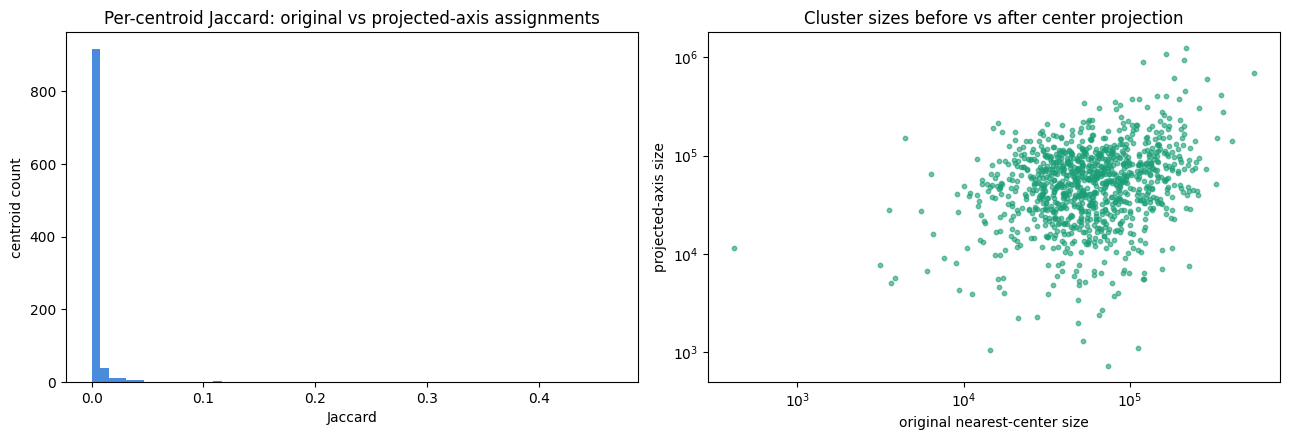

In [31]:
FULL_K = 1000
FULL_LAYER = 5
FULL_ROOT = Path("/orfeo/scratch/dssc/zenocosini/dalg-cache/pile_gemma2b_activations")
FULL_CENTROIDS_PATH = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/centroids.pt"
FULL_ORIGINAL_ASSIGNMENTS = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_assignments.pt"
FULL_PROJECTED_ASSIGNMENTS = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_projected_axis_assignments.pt"
FULL_PROJECTED_SUMMARY = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_projected_axis_summary.json"

display(pd.DataFrame([
    {"artifact": "activation shard root", "path": str(FULL_ROOT), "exists": FULL_ROOT.exists()},
    {"artifact": "K=1000 centers", "path": str(FULL_CENTROIDS_PATH), "exists": FULL_CENTROIDS_PATH.exists()},
    {"artifact": "original nearest-center assignments", "path": str(FULL_ORIGINAL_ASSIGNMENTS), "exists": FULL_ORIGINAL_ASSIGNMENTS.exists()},
    {"artifact": "projected-axis assignments", "path": str(FULL_PROJECTED_ASSIGNMENTS), "exists": FULL_PROJECTED_ASSIGNMENTS.exists()},
    {"artifact": "projected-axis summary", "path": str(FULL_PROJECTED_SUMMARY), "exists": FULL_PROJECTED_SUMMARY.exists()},
]))

if FULL_PROJECTED_SUMMARY.exists():
    full_summary = json.loads(FULL_PROJECTED_SUMMARY.read_text())
    display(pd.DataFrame([
        {"metric": "axis_source", "value": full_summary["axis_source"]},
        {"metric": "num_items", "value": full_summary["num_items"]},
        {"metric": "same_centroid_agreement", "value": full_summary["same_centroid_agreement"]},
        {"metric": "NMI", "value": full_summary["nmi"]},
        {"metric": "mean_per_centroid_jaccard", "value": full_summary["mean_per_centroid_jaccard"]},
        {"metric": "median_per_centroid_jaccard", "value": full_summary["median_per_centroid_jaccard"]},
        {"metric": "nonempty_projected_clusters", "value": full_summary["nonempty_projected_clusters"]},
    ]))

    sizes = pd.DataFrame({
        "centroid": np.arange(full_summary["K"]),
        "original_size": full_summary["original_cluster_sizes"],
        "projected_size": full_summary["projected_cluster_sizes"],
        "jaccard": full_summary["per_centroid_jaccard"],
    })
    display(sizes.describe())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(sizes["jaccard"], bins=60, color="#2a78d6", alpha=0.85)
    axes[0].set_title("Per-centroid Jaccard: original vs projected-axis assignments")
    axes[0].set_xlabel("Jaccard")
    axes[0].set_ylabel("centroid count")

    axes[1].scatter(sizes["original_size"], sizes["projected_size"], s=10, alpha=0.6, color="#1b9e77")
    axes[1].set_title("Cluster sizes before vs after center projection")
    axes[1].set_xlabel("original nearest-center size")
    axes[1].set_ylabel("projected-axis size")
    axes[1].set_xscale("symlog")
    axes[1].set_yscale("symlog")
    plt.tight_layout()
    plt.show()
else:
    print("Projected-axis summary is not present yet. Run the full projected-center assignment job first.")


## 7. Within-Cluster Angular Coherence for K=1000

For each original nearest-center cluster, compute the average pairwise cosine similarity among the points assigned to it. This is a direct test for angularly tight subcones inside the larger activation cone.

The computation is streaming and does not materialize pairwise matrices. If `z_i = x_i / ||x_i||`, then for a cluster with `n` points:

`mean_{i != j} cos(x_i, x_j) = (||sum_i z_i||^2 - n) / (n * (n - 1))`.

Interpretation: values above the global average pairwise cosine suggest angularly coherent sub-cones; values close to the global average suggest the cluster is not much tighter than the whole cone in raw cosine geometry.

,artifact,path,exists
0,activation shard root,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
1,original nearest-center assignments,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
2,intracluster cosine summary,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True


,metric,value
0,num_items,7.368794e+07
1,K,1.000000e+03
2,global_avg_pairwise_cosine,8.324464e-01
3,cluster_mean_of_avg_pairwise_cosine,8.904108e-01
4,cluster_median_avg_pairwise_cosine,8.923103e-01
5,cluster_min_avg_pairwise_cosine,7.812684e-01
6,cluster_max_avg_pairwise_cosine,9.756829e-01
7,mean_lift_over_global,5.796439e-02
8,median_lift_over_global,5.986389e-02


,cluster,size,avg_pairwise_cosine,lift_over_global
471,471,14351,0.975683,0.143236
551,551,19693,0.975600,0.143153
668,668,184863,0.972606,0.140160
628,628,57357,0.971695,0.139249
110,110,155726,0.971208,0.138761
519,519,223627,0.970682,0.138235
494,494,7645,0.970608,0.138162
91,91,362955,0.969322,0.136875
656,656,229333,0.967608,0.135161
368,368,37581,0.967341,0.134895


,cluster,size,avg_pairwise_cosine,lift_over_global
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,73687.936000,0.890411,0.057964
std,288.819436,57194.461082,0.040422,0.040422
min,0.000000,413.000000,0.781268,-0.051178
25%,249.750000,35702.750000,0.855854,0.023408
50%,499.500000,56763.500000,0.892310,0.059864
75%,749.250000,92937.500000,0.924361,0.091915
max,999.000000,561332.000000,0.975683,0.143236


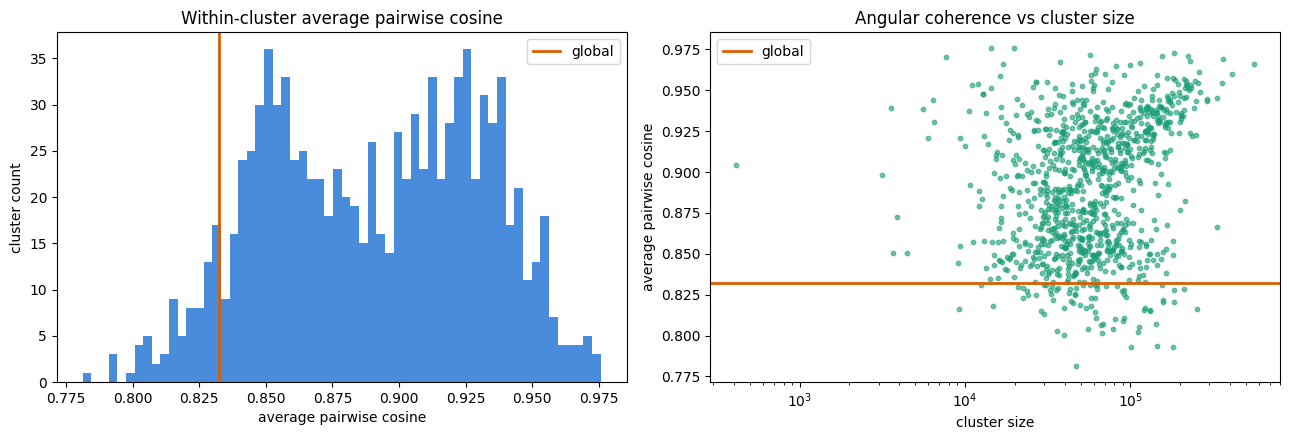

In [32]:
FULL_INTRACLUSTER_COSINE_SUMMARY = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_intracluster_cosine_summary.json"

display(pd.DataFrame([
    {"artifact": "activation shard root", "path": str(FULL_ROOT), "exists": FULL_ROOT.exists()},
    {"artifact": "original nearest-center assignments", "path": str(FULL_ORIGINAL_ASSIGNMENTS), "exists": FULL_ORIGINAL_ASSIGNMENTS.exists()},
    {"artifact": "intracluster cosine summary", "path": str(FULL_INTRACLUSTER_COSINE_SUMMARY), "exists": FULL_INTRACLUSTER_COSINE_SUMMARY.exists()},
]))

if FULL_INTRACLUSTER_COSINE_SUMMARY.exists():
    intra_summary = json.loads(FULL_INTRACLUSTER_COSINE_SUMMARY.read_text())
    display(pd.DataFrame([
        {"metric": "num_items", "value": intra_summary["num_items"]},
        {"metric": "K", "value": intra_summary["K"]},
        {"metric": "global_avg_pairwise_cosine", "value": intra_summary["global_avg_pairwise_cosine"]},
        {"metric": "cluster_mean_of_avg_pairwise_cosine", "value": intra_summary["cluster_mean_of_avg_pairwise_cosine"]},
        {"metric": "cluster_median_avg_pairwise_cosine", "value": intra_summary["cluster_median_avg_pairwise_cosine"]},
        {"metric": "cluster_min_avg_pairwise_cosine", "value": intra_summary["cluster_min_avg_pairwise_cosine"]},
        {"metric": "cluster_max_avg_pairwise_cosine", "value": intra_summary["cluster_max_avg_pairwise_cosine"]},
        {"metric": "mean_lift_over_global", "value": intra_summary["cluster_mean_lift_over_global"]},
        {"metric": "median_lift_over_global", "value": intra_summary["cluster_median_lift_over_global"]},
    ]))

    intra_df = pd.DataFrame({
        "cluster": np.arange(intra_summary["K"]),
        "size": intra_summary["cluster_sizes"],
        "avg_pairwise_cosine": intra_summary["cluster_avg_pairwise_cosine"],
        "lift_over_global": intra_summary["cluster_lift_over_global"],
    }).sort_values("avg_pairwise_cosine", ascending=False)
    display(intra_df.head(20))
    display(intra_df.describe())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(intra_df["avg_pairwise_cosine"].dropna(), bins=60, color="#2a78d6", alpha=0.85)
    axes[0].axvline(intra_summary["global_avg_pairwise_cosine"], color="#d95f02", linewidth=2, label="global")
    axes[0].set_title("Within-cluster average pairwise cosine")
    axes[0].set_xlabel("average pairwise cosine")
    axes[0].set_ylabel("cluster count")
    axes[0].legend()

    axes[1].scatter(intra_df["size"], intra_df["avg_pairwise_cosine"], s=10, alpha=0.6, color="#1b9e77")
    axes[1].axhline(intra_summary["global_avg_pairwise_cosine"], color="#d95f02", linewidth=2, label="global")
    axes[1].set_title("Angular coherence vs cluster size")
    axes[1].set_xlabel("cluster size")
    axes[1].set_ylabel("average pairwise cosine")
    axes[1].set_xscale("log")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Intracluster cosine summary is not present yet. Run the full streaming computation first.")


## 8. Axis-Removed Within-Cluster Angular Coherence

This is the centered version of the previous test. It removes the full-data cone axis from every activation point before computing cosine coherence inside each original K=1000 cluster.

For unit axis `u`, each point becomes `r_i = x_i - (x_i @ u) u`; then we normalize `r_i` and use the same streaming pairwise-cosine identity. This asks whether clusters form smaller angular subcones after the dominant global cone direction is removed.

,artifact,path,exists
0,activation shard root,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
1,original nearest-center assignments,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
2,full-data cone axis bundle,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True
3,axis-removed intracluster cosine summary,/orfeo/scratch/dssc/zenocosini/dalg-cache/pile...,True


,metric,value
0,num_items,73687936
1,K,1000
2,removed_axis_source,points_mean_all_data
3,global_avg_pairwise_cosine_after_axis_removal,0.001357
4,cluster_mean_avg_pairwise_cosine_after_axis_re...,0.39184
5,cluster_weighted_mean_avg_pairwise_cosine_afte...,0.420945
6,cluster_median_avg_pairwise_cosine_after_axis_...,0.398084
7,mean_lift_over_centered_global,0.390483
8,median_lift_over_centered_global,0.396727


,cluster,size,avg_pairwise_cosine_after_axis_removal,lift_over_centered_global
551,551,19693,0.887012,0.885655
494,494,7645,0.864141,0.862783
628,628,57357,0.853313,0.851956
368,368,37581,0.852969,0.851612
110,110,155726,0.850050,0.848693
471,471,14351,0.833383,0.832026
544,544,81819,0.823017,0.821660
206,206,99347,0.815714,0.814356
519,519,223627,0.809046,0.807689
37,37,17078,0.801347,0.799990


,cluster,size,avg_pairwise_cosine_after_axis_removal,lift_over_centered_global
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,73687.936000,0.391840,0.390483
std,288.819436,57194.461082,0.187014,0.187014
min,0.000000,413.000000,0.093702,0.092345
25%,249.750000,35702.750000,0.206916,0.205559
50%,499.500000,56763.500000,0.398084,0.396727
75%,749.250000,92937.500000,0.545153,0.543796
max,999.000000,561332.000000,0.887012,0.885655


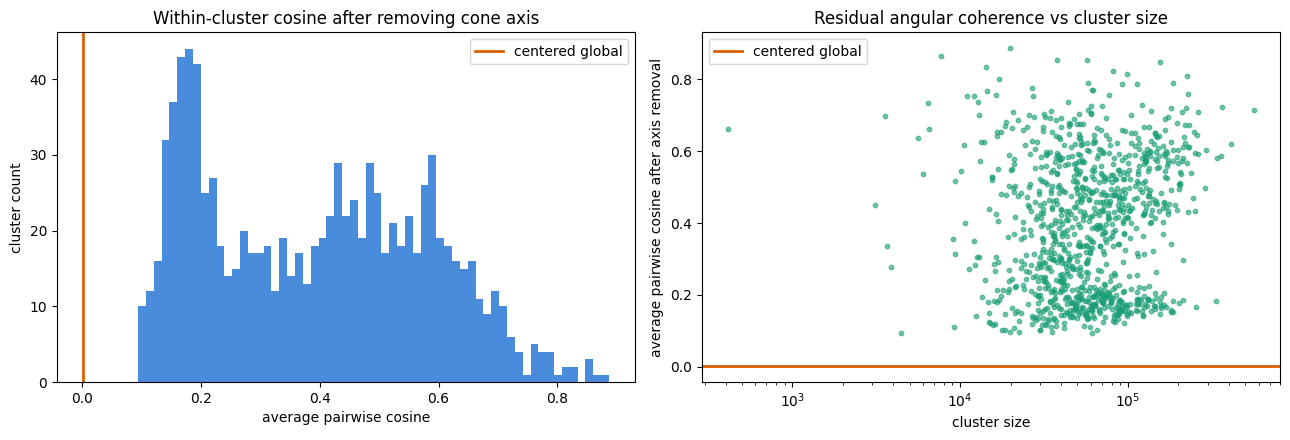

In [33]:
FULL_AXIS_CENTERED_COSINE_SUMMARY = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_axis_removed_intracluster_cosine_summary.json"
FULL_PROJECTED_ASSIGNMENTS = FULL_ROOT / f"centroids/k{FULL_K}_L{FULL_LAYER:02d}/kmeans_centroid_projected_axis_assignments.pt"

display(pd.DataFrame([
    {"artifact": "activation shard root", "path": str(FULL_ROOT), "exists": FULL_ROOT.exists()},
    {"artifact": "original nearest-center assignments", "path": str(FULL_ORIGINAL_ASSIGNMENTS), "exists": FULL_ORIGINAL_ASSIGNMENTS.exists()},
    {"artifact": "full-data cone axis bundle", "path": str(FULL_PROJECTED_ASSIGNMENTS), "exists": FULL_PROJECTED_ASSIGNMENTS.exists()},
    {"artifact": "axis-removed intracluster cosine summary", "path": str(FULL_AXIS_CENTERED_COSINE_SUMMARY), "exists": FULL_AXIS_CENTERED_COSINE_SUMMARY.exists()},
]))

if FULL_AXIS_CENTERED_COSINE_SUMMARY.exists():
    centered_summary = json.loads(FULL_AXIS_CENTERED_COSINE_SUMMARY.read_text())
    display(pd.DataFrame([
        {"metric": "num_items", "value": centered_summary["num_items"]},
        {"metric": "K", "value": centered_summary["K"]},
        {"metric": "removed_axis_source", "value": centered_summary["removed_axis_source"]},
        {"metric": "global_avg_pairwise_cosine_after_axis_removal", "value": centered_summary["global_avg_pairwise_cosine_after_axis_removal"]},
        {"metric": "cluster_mean_avg_pairwise_cosine_after_axis_removal", "value": centered_summary["cluster_mean_avg_pairwise_cosine_after_axis_removal"]},
        {"metric": "cluster_weighted_mean_avg_pairwise_cosine_after_axis_removal", "value": centered_summary["cluster_weighted_mean_avg_pairwise_cosine_after_axis_removal"]},
        {"metric": "cluster_median_avg_pairwise_cosine_after_axis_removal", "value": centered_summary["cluster_median_avg_pairwise_cosine_after_axis_removal"]},
        {"metric": "mean_lift_over_centered_global", "value": centered_summary["cluster_mean_lift_over_centered_global"]},
        {"metric": "median_lift_over_centered_global", "value": centered_summary["cluster_median_lift_over_centered_global"]},
    ]))

    centered_df = pd.DataFrame({
        "cluster": np.arange(centered_summary["K"]),
        "size": centered_summary["cluster_sizes"],
        "avg_pairwise_cosine_after_axis_removal": centered_summary["cluster_avg_pairwise_cosine_after_axis_removal"],
        "lift_over_centered_global": centered_summary["cluster_lift_over_centered_global"],
    }).sort_values("avg_pairwise_cosine_after_axis_removal", ascending=False)
    display(centered_df.head(20))
    display(centered_df.describe())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].hist(centered_df["avg_pairwise_cosine_after_axis_removal"].dropna(), bins=60, color="#2a78d6", alpha=0.85)
    axes[0].axvline(centered_summary["global_avg_pairwise_cosine_after_axis_removal"], color="#d95f02", linewidth=2, label="centered global")
    axes[0].set_title("Within-cluster cosine after removing cone axis")
    axes[0].set_xlabel("average pairwise cosine")
    axes[0].set_ylabel("cluster count")
    axes[0].legend()

    axes[1].scatter(centered_df["size"], centered_df["avg_pairwise_cosine_after_axis_removal"], s=10, alpha=0.6, color="#1b9e77")
    axes[1].axhline(centered_summary["global_avg_pairwise_cosine_after_axis_removal"], color="#d95f02", linewidth=2, label="centered global")
    axes[1].set_title("Residual angular coherence vs cluster size")
    axes[1].set_xlabel("cluster size")
    axes[1].set_ylabel("average pairwise cosine after axis removal")
    axes[1].set_xscale("log")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Axis-removed intracluster cosine summary is not present yet. Run the full streaming computation first.")


## 9. Previous K=12 Medoid Projection Check

This smaller check uses the materialized 100K KMedoids cache. The full experiment above uses the K=1000 centers and all layer-5 activation tokens.

In [34]:
KMEDOIDS_ACTIVATIONS = KMEDOIDS_RUN / "data/activations.npy"
KMEDOIDS_MEDOIDS = KMEDOIDS_RUN / "k12/medoids.npy"
KMEDOIDS_LABELS = KMEDOIDS_RUN / "k12/labels.npy"
PROJECTED_LABELS = KMEDOIDS_RUN / "k12/projected_axis_medoid_labels.npy"
PROJECTED_AXIS_INFO = KMEDOIDS_RUN / "k12/projected_axis_info.npz"

for p in [KMEDOIDS_ACTIVATIONS, KMEDOIDS_MEDOIDS, KMEDOIDS_LABELS]:
    if not p.exists():
        raise FileNotFoundError(p)

X_all = np.load(KMEDOIDS_ACTIVATIONS, mmap_mode="r")
medoids = np.load(KMEDOIDS_MEDOIDS).astype(np.float32, copy=False)
original_labels = np.load(KMEDOIDS_LABELS).astype(np.int64, copy=False)
assert X_all.shape[0] == original_labels.shape[0]
assert X_all.shape[1] == medoids.shape[1]

display(pd.DataFrame([
    {"artifact": "activations", "path": str(KMEDOIDS_ACTIVATIONS), "shape": tuple(X_all.shape)},
    {"artifact": "medoids", "path": str(KMEDOIDS_MEDOIDS), "shape": tuple(medoids.shape)},
    {"artifact": "original labels", "path": str(KMEDOIDS_LABELS), "shape": tuple(original_labels.shape)},
]))


def unit_vector(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float64)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("cannot normalize a zero vector")
    return (v / norm).astype(np.float32)


def chunked_axis_from_points(X_memmap: np.ndarray, *, normalize_rows: bool, chunk_size: int) -> np.ndarray:
    acc = np.zeros(X_memmap.shape[1], dtype=np.float64)
    count = 0
    for start in range(0, X_memmap.shape[0], chunk_size):
        xb = np.asarray(X_memmap[start:start + chunk_size], dtype=np.float32)
        if normalize_rows:
            norms = np.linalg.norm(xb, axis=1, keepdims=True)
            xb = xb / np.maximum(norms, 1e-12)
        acc += xb.sum(axis=0, dtype=np.float64)
        count += xb.shape[0]
    return unit_vector(acc / count)


def estimate_cone_axis(X_memmap: np.ndarray, medoids: np.ndarray, source: str) -> np.ndarray:
    if source == "points_mean":
        axis = chunked_axis_from_points(X_memmap, normalize_rows=False, chunk_size=ASSIGNMENT_CHUNK_SIZE)
    elif source == "normalized_points_mean":
        axis = chunked_axis_from_points(X_memmap, normalize_rows=True, chunk_size=ASSIGNMENT_CHUNK_SIZE)
    elif source == "medoids_mean":
        axis = unit_vector(medoids.mean(axis=0))
    elif source == "normalized_medoids_mean":
        mn = medoids / np.maximum(np.linalg.norm(medoids, axis=1, keepdims=True), 1e-12)
        axis = unit_vector(mn.mean(axis=0))
    else:
        raise ValueError(f"unknown AXIS_SOURCE={source!r}")
    if float(medoids.mean(axis=0) @ axis) < 0:
        axis = -axis
    return axis


def assign_to_projected_medoids(
    X_memmap: np.ndarray,
    medoids: np.ndarray,
    axis: np.ndarray,
    *,
    chunk_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    axis = axis.astype(np.float32, copy=False)
    medoid_axis_pos = medoids @ axis
    projected_norm_sq = medoid_axis_pos ** 2
    labels = np.empty(X_memmap.shape[0], dtype=np.int64)
    for start in range(0, X_memmap.shape[0], chunk_size):
        xb = np.asarray(X_memmap[start:start + chunk_size], dtype=np.float32)
        point_axis_pos = xb @ axis
        distances_without_point_norm = (
            projected_norm_sq[None, :] - 2.0 * point_axis_pos[:, None] * medoid_axis_pos[None, :]
        )
        labels[start:start + xb.shape[0]] = distances_without_point_norm.argmin(axis=1)
    return labels, medoid_axis_pos


axis = estimate_cone_axis(X_all, medoids, AXIS_SOURCE)
projected_labels, medoid_axis_pos = assign_to_projected_medoids(
    X_all, medoids, axis, chunk_size=ASSIGNMENT_CHUNK_SIZE
)

if SAVE_PROJECTED_ASSIGNMENTS:
    np.save(PROJECTED_LABELS, projected_labels)
    np.savez(
        PROJECTED_AXIS_INFO,
        axis=axis,
        medoid_axis_pos=medoid_axis_pos,
        axis_source=np.array(AXIS_SOURCE),
        activations_path=np.array(str(KMEDOIDS_ACTIVATIONS)),
        medoids_path=np.array(str(KMEDOIDS_MEDOIDS)),
        labels_path=np.array(str(KMEDOIDS_LABELS)),
    )
    print(f"saved projected labels: {PROJECTED_LABELS}")
    print(f"saved axis info: {PROJECTED_AXIS_INFO}")


,artifact,path,shape
0,activations,/orfeo/cephfs/scratch/dssc/malessi/decomposing...,"(100128, 2048)"
1,medoids,/orfeo/cephfs/scratch/dssc/malessi/decomposing...,"(12, 2048)"
2,original labels,/orfeo/cephfs/scratch/dssc/malessi/decomposing...,"(100128,)"


saved projected labels: /orfeo/cephfs/scratch/dssc/malessi/decomposing-activations-local-geometry/outputs/experiments/pile_wikipedia_100K_layer05_kmedoids/full_100k_clean/k12/projected_axis_medoid_labels.npy
saved axis info: /orfeo/cephfs/scratch/dssc/malessi/decomposing-activations-local-geometry/outputs/experiments/pile_wikipedia_100K_layer05_kmedoids/full_100k_clean/k12/projected_axis_info.npz


,metric,value
0,same_medoid_agreement,0.225491
1,NMI,0.276746
2,mean_per_medoid_jaccard,0.150088
3,median_per_medoid_jaccard,0.048077
4,axis_source,points_mean


,medoid,axis_position,axis_rank,original_size,projected_size,kept,jaccard,recall_original_kept,precision_projected_from_original
5,5,100.662338,0,11098,7698,6555,0.535495,0.590647,0.851520
2,2,108.391510,1,9139,7793,1733,0.114021,0.189627,0.222379
6,6,113.417480,2,5462,4999,559,0.056453,0.102343,0.111822
3,3,113.779732,3,4454,1358,113,0.019828,0.025370,0.083211
11,11,114.666084,4,18692,1820,427,0.021260,0.022844,0.234615
0,0,115.378761,5,5707,6121,405,0.035455,0.070965,0.066166
4,4,119.904892,6,3288,8076,381,0.034690,0.115876,0.047177
7,7,121.546638,7,20125,5251,969,0.039702,0.048149,0.184536
8,8,123.695190,8,1309,20740,574,0.026729,0.438503,0.027676
9,9,138.231155,9,10869,19151,3735,0.142096,0.343638,0.195029


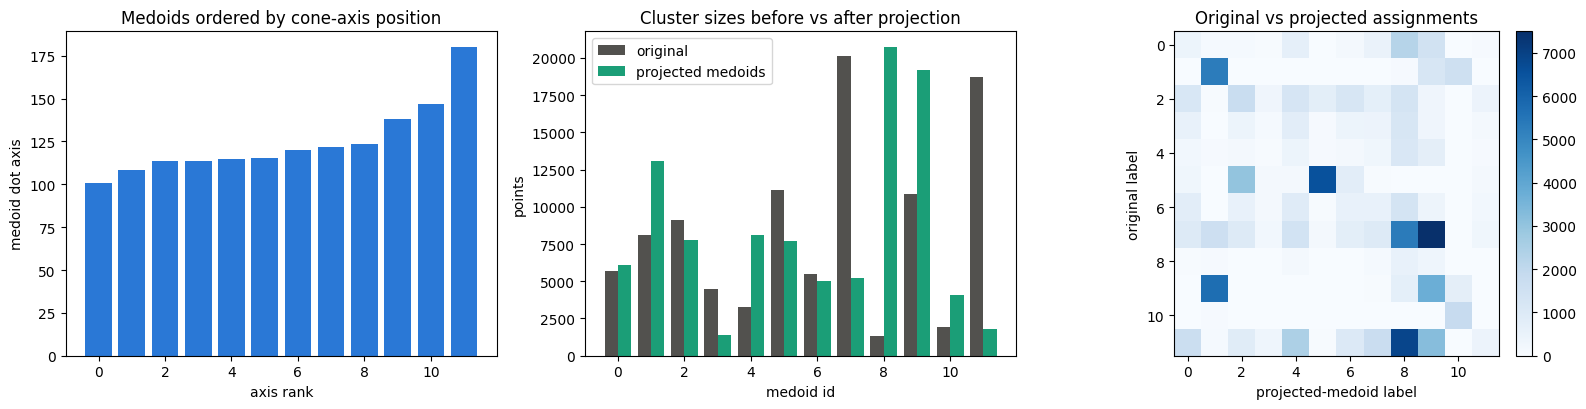

In [35]:
def entropy_from_counts(counts: np.ndarray) -> float:
    counts = counts[counts > 0].astype(np.float64)
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())


def nmi_from_contingency(contingency: np.ndarray) -> float:
    n = contingency.sum()
    row = contingency.sum(axis=1)
    col = contingency.sum(axis=0)
    nz = contingency > 0
    i, j = np.where(nz)
    observed = contingency[nz].astype(np.float64)
    expected = row[i].astype(np.float64) * col[j].astype(np.float64) / n
    mi = float((observed / n * np.log(observed / expected)).sum())
    h_row = entropy_from_counts(row)
    h_col = entropy_from_counts(col)
    return mi / np.sqrt(h_row * h_col) if h_row > 0 and h_col > 0 else 0.0


K_MEDOIDS = medoids.shape[0]
contingency = np.bincount(
    original_labels * K_MEDOIDS + projected_labels,
    minlength=K_MEDOIDS * K_MEDOIDS,
).reshape(K_MEDOIDS, K_MEDOIDS)

original_sizes = contingency.sum(axis=1)
projected_sizes = contingency.sum(axis=0)
kept = np.diag(contingency)
union = original_sizes + projected_sizes - kept
jaccard = np.divide(kept, union, out=np.zeros_like(kept, dtype=np.float64), where=union > 0)
recall = np.divide(kept, original_sizes, out=np.zeros_like(kept, dtype=np.float64), where=original_sizes > 0)
precision = np.divide(kept, projected_sizes, out=np.zeros_like(kept, dtype=np.float64), where=projected_sizes > 0)

same_medoid_agreement = float((original_labels == projected_labels).mean())
nmi = nmi_from_contingency(contingency)

display(pd.DataFrame([
    {"metric": "same_medoid_agreement", "value": same_medoid_agreement},
    {"metric": "NMI", "value": nmi},
    {"metric": "mean_per_medoid_jaccard", "value": float(jaccard.mean())},
    {"metric": "median_per_medoid_jaccard", "value": float(np.median(jaccard))},
    {"metric": "axis_source", "value": AXIS_SOURCE},
]))

medoid_df = pd.DataFrame({
    "medoid": np.arange(K_MEDOIDS),
    "axis_position": medoid_axis_pos,
    "axis_rank": np.argsort(np.argsort(medoid_axis_pos)),
    "original_size": original_sizes,
    "projected_size": projected_sizes,
    "kept": kept,
    "jaccard": jaccard,
    "recall_original_kept": recall,
    "precision_projected_from_original": precision,
}).sort_values("axis_position")
display(medoid_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].bar(np.arange(K_MEDOIDS), medoid_df["axis_position"], color="#2a78d6")
axes[0].set_title("Medoids ordered by cone-axis position")
axes[0].set_xlabel("axis rank")
axes[0].set_ylabel("medoid dot axis")

width = 0.4
x = np.arange(K_MEDOIDS)
axes[1].bar(x - width / 2, original_sizes, width=width, label="original", color="#52514e")
axes[1].bar(x + width / 2, projected_sizes, width=width, label="projected medoids", color="#1b9e77")
axes[1].set_title("Cluster sizes before vs after projection")
axes[1].set_xlabel("medoid id")
axes[1].set_ylabel("points")
axes[1].legend()

im = axes[2].imshow(contingency, cmap="Blues")
axes[2].set_title("Original vs projected assignments")
axes[2].set_xlabel("projected-medoid label")
axes[2].set_ylabel("original label")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### 9.1 Axis-source sanity check

In [36]:
axis_rows = []
for source in ["points_mean", "normalized_points_mean", "medoids_mean", "normalized_medoids_mean"]:
    axis_alt = estimate_cone_axis(X_all, medoids, source)
    labels_alt, _axis_pos_alt = assign_to_projected_medoids(
        X_all, medoids, axis_alt, chunk_size=ASSIGNMENT_CHUNK_SIZE
    )
    cont_alt = np.bincount(
        original_labels * K_MEDOIDS + labels_alt,
        minlength=K_MEDOIDS * K_MEDOIDS,
    ).reshape(K_MEDOIDS, K_MEDOIDS)
    orig_alt = cont_alt.sum(axis=1)
    proj_alt = cont_alt.sum(axis=0)
    kept_alt = np.diag(cont_alt)
    union_alt = orig_alt + proj_alt - kept_alt
    jac_alt = np.divide(
        kept_alt, union_alt, out=np.zeros_like(kept_alt, dtype=np.float64), where=union_alt > 0
    )
    axis_rows.append({
        "axis_source": source,
        "same_medoid_agreement": float((original_labels == labels_alt).mean()),
        "NMI": nmi_from_contingency(cont_alt),
        "mean_jaccard": float(jac_alt.mean()),
        "median_jaccard": float(np.median(jac_alt)),
    })

display(pd.DataFrame(axis_rows).sort_values("same_medoid_agreement", ascending=False))


,axis_source,same_medoid_agreement,NMI,mean_jaccard,median_jaccard
3,normalized_medoids_mean,0.244966,0.268685,0.166982,0.057022
2,medoids_mean,0.244008,0.270530,0.167613,0.056853
1,normalized_points_mean,0.226210,0.275719,0.150816,0.048577
0,points_mean,0.225491,0.276746,0.150088,0.048077


## 10. Optional Gaussian Baseline

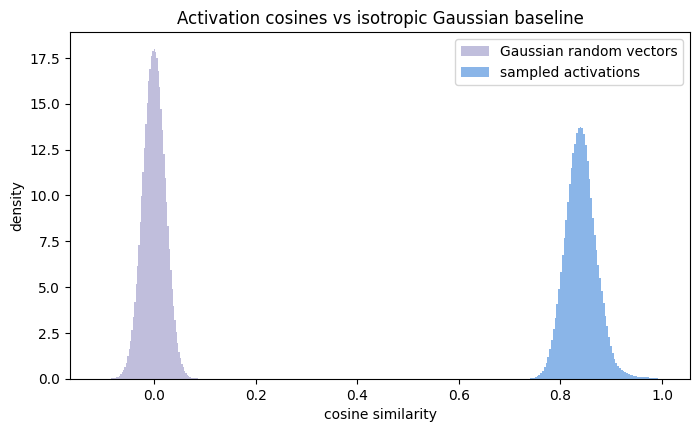

In [37]:
g = torch.Generator().manual_seed(SEED)
Z = torch.randn(X.shape, generator=g)
Zn = F.normalize(Z, dim=1)
baseline_cos = Zn @ Zn.T
baseline_values = baseline_cos[mask].numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(baseline_values, bins=80, density=True, color="#7570b3", alpha=0.45, label="Gaussian random vectors")
ax.hist(cos_values, bins=80, density=True, color="#2a78d6", alpha=0.55, label="sampled activations")
ax.set_title("Activation cosines vs isotropic Gaussian baseline")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("density")
ax.legend()
plt.show()